# Gen 1 — relatório reprodutível

Lê todos os runs em `artifacts/runs/*__gen1__*__*-aggr-*`, monta a matriz
pareada `binary` × `mc8` (13 pares), e roda McNemar e plots.

Pré-requisitos: os runs precisam existir (veja `docs/relatorio_gen1.md`
para os comandos de reprodução). Dependências extras:
`uv sync --group report`.

In [3]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

from ptbr_market.evaluation import mcnemar_test

RUNS_DIR = Path('../artifacts/runs')
assert RUNS_DIR.exists(), f'Rodar a partir de notebooks/; RUNS_DIR={RUNS_DIR.resolve()}'

## 1. Carregar metadata de todos os runs aggr-bin / aggr-mc8

In [4]:
def load_runs(runs_dir: Path) -> pd.DataFrame:
    rows = []
    for d in sorted(runs_dir.iterdir()):
        meta_path = d / 'metadata.json'
        if not meta_path.exists():
            continue
        meta = json.loads(meta_path.read_text())
        variant = meta.get('variant', '')
        if '-aggr-' not in variant:
            continue
        target = meta['config'].get('target', {})
        mode = target.get('mode', 'binary')
        tag = f"mc{target.get('num_classes')}" if mode == 'multiclass' else 'bin'
        rows.append({
            'run_id': meta['run_id'],
            'model': meta['model'],
            'representation': meta['config']['representation'],
            'target_tag': tag,
            'threshold': meta['threshold']['value'],
            'pr_auc': meta['metrics']['pr_auc'],
            'roc_auc': meta['metrics']['roc_auc'],
            'f1_minority': meta['metrics']['f1_minority'],
            'precision_minority': meta['metrics']['precision_minority'],
            'recall_minority': meta['metrics']['recall_minority'],
            'latency_ms_per_1k': meta['efficiency']['latency_ms_per_1k'],
            'run_dir': str(d),
        })
    return pd.DataFrame.from_records(rows)


summary = load_runs(RUNS_DIR).sort_values(['representation', 'model', 'target_tag'])
print(f'{len(summary)} runs carregados')
summary[['representation', 'model', 'target_tag', 'f1_minority', 'pr_auc', 'latency_ms_per_1k']]

26 runs carregados


,representation,model,target_tag,f1_minority,pr_auc,latency_ms_per_1k
20,bow,complementnb,bin,0.718182,0.654627,0.643987
8,bow,complementnb,mc8,0.705882,0.680143,0.991173
22,bow,lightgbm,bin,0.782709,0.876999,6.776391
9,bow,lightgbm,mc8,0.819709,0.909240,25.486356
18,bow,linearsvc,bin,0.790027,0.858068,1.054374
5,bow,linearsvc,mc8,0.806134,0.878565,3.043048
19,bow,logreg,bin,0.785933,0.858657,0.323295
6,bow,logreg,mc8,0.806738,0.869227,0.914519
21,bow,multinomialnb,bin,0.721689,0.658647,0.639674
7,bow,multinomialnb,mc8,0.715211,0.688934,1.002056


## 2. Pareamento binary vs mc8

In [5]:
def pair(df: pd.DataFrame) -> pd.DataFrame:
    b = df[df.target_tag == 'bin'].set_index(['representation', 'model'])
    m = df[df.target_tag == 'mc8'].set_index(['representation', 'model'])
    cols = ['f1_minority', 'pr_auc', 'precision_minority', 'recall_minority',
            'latency_ms_per_1k', 'threshold', 'run_dir']
    out = b[cols].join(m[cols], lsuffix='_bin', rsuffix='_mc8', how='inner')
    out['delta_f1_minority'] = out.f1_minority_mc8 - out.f1_minority_bin
    out['delta_pr_auc'] = out.pr_auc_mc8 - out.pr_auc_bin
    return out.reset_index()

paired = pair(summary)
paired[['representation', 'model', 'f1_minority_bin', 'f1_minority_mc8',
        'delta_f1_minority', 'pr_auc_bin', 'pr_auc_mc8', 'delta_pr_auc']]


,representation,model,f1_minority_bin,f1_minority_mc8,delta_f1_minority,pr_auc_bin,pr_auc_mc8,delta_pr_auc
0,bow,complementnb,0.718182,0.705882,-0.012299,0.654627,0.680143,0.025516
1,bow,lightgbm,0.782709,0.819709,0.037001,0.876999,0.909240,0.032241
2,bow,linearsvc,0.790027,0.806134,0.016107,0.858068,0.878565,0.020497
3,bow,logreg,0.785933,0.806738,0.020806,0.858657,0.869227,0.010571
4,bow,multinomialnb,0.721689,0.715211,-0.006478,0.658647,0.688934,0.030287
5,fasttext,lightgbm,0.764266,0.780631,0.016365,0.847510,0.861343,0.013833
6,fasttext,linearsvc,0.734307,0.745406,0.011098,0.787962,0.806350,0.018388
7,fasttext,logreg,0.703913,0.719395,0.015482,0.744799,0.781788,0.036989
8,tfidf,complementnb,0.713735,0.745998,0.032263,0.780433,0.786228,0.005795
9,tfidf,lightgbm,0.799186,0.833447,0.034261,0.885471,0.913186,0.027715


## 3. F1-min e PR-AUC lado a lado

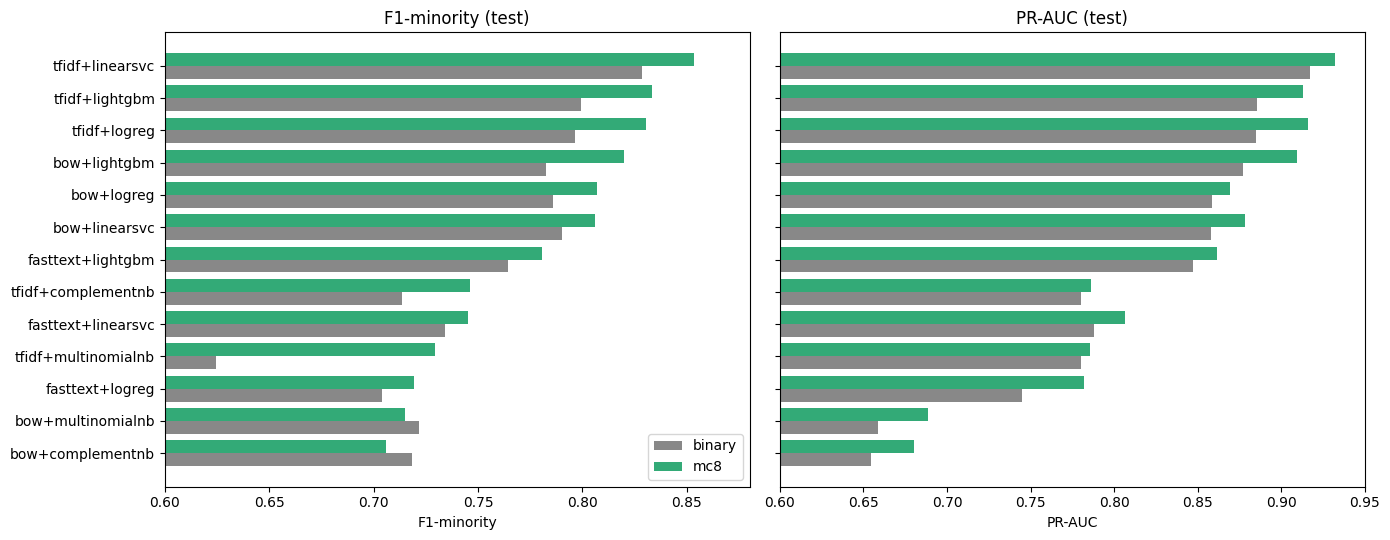

In [6]:
def _labels(df):
    return [f'{r}+{m}' for r, m in zip(df.representation, df.model)]


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
order = paired.sort_values('f1_minority_mc8', ascending=True)
y = np.arange(len(order))

axes[0].barh(y - 0.2, order.f1_minority_bin, height=0.4, label='binary', color='#888')
axes[0].barh(y + 0.2, order.f1_minority_mc8, height=0.4, label='mc8', color='#3a7')
axes[0].set_yticks(y, _labels(order))
axes[0].set_xlabel('F1-minority')
axes[0].set_title('F1-minority (test)')
axes[0].legend(loc='lower right')
axes[0].set_xlim(0.6, 0.88)

axes[1].barh(y - 0.2, order.pr_auc_bin, height=0.4, label='binary', color='#888')
axes[1].barh(y + 0.2, order.pr_auc_mc8, height=0.4, label='mc8', color='#3a7')
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('PR-AUC (test)')
axes[1].set_xlim(0.6, 0.95)

fig.tight_layout()
plt.show()


## 4. McNemar pareado (binary vs mc8)

`b` = binary acerta e mc8 erra; `c` = binary erra e mc8 acerta. χ² com
correção de continuidade; binomial exato quando `b+c < 25`
(ver `src/ptbr_market/evaluation.py`).

In [7]:
def mcnemar_rows(paired: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in paired.iterrows():
        pb = pd.read_csv(Path(r.run_dir_bin) / 'predictions.csv')
        pm = pd.read_csv(Path(r.run_dir_mc8) / 'predictions.csv')
        j = pb[['index', 'y_true', 'y_pred']].merge(
            pm[['index', 'y_true', 'y_pred']], on='index',
            suffixes=('_bin', '_mc8'),
        )
        assert (j.y_true_bin == j.y_true_mc8).all()
        res = mcnemar_test(j.y_true_bin.to_numpy(), j.y_pred_bin.to_numpy(),
                           j.y_pred_mc8.to_numpy())
        rows.append({
            'representation': r.representation,
            'model': r.model,
            'b_bin_only_correct': res['b'],
            'c_mc8_only_correct': res['c'],
            'statistic': res['statistic'],
            'p_value': res['p_value'],
            'winner': ('mc8' if res['c'] > res['b']
                       else 'binary' if res['b'] > res['c'] else 'tie'),
            'sig_0.05': res['p_value'] < 0.05,
        })
    return pd.DataFrame.from_records(rows)

mcnemar = mcnemar_rows(paired)
mcnemar.sort_values('p_value')

,representation,model,b_bin_only_correct,c_mc8_only_correct,statistic,p_value,winner,sig_0.05
10,tfidf,linearsvc,102,256,65.388268,6.150394e-16,mc8,True
11,tfidf,logreg,107,256,60.341598,7.974423e-15,mc8,True
9,tfidf,lightgbm,141,298,55.435080,9.659712e-14,mc8,True
1,bow,lightgbm,162,313,47.368421,5.882272e-12,mc8,True
3,bow,logreg,212,366,40.500000,1.966160e-10,mc8,True
4,bow,multinomialnb,293,468,39.784494,2.835876e-10,mc8,True
5,fasttext,lightgbm,156,285,37.151927,1.092747e-09,mc8,True
0,bow,complementnb,343,486,24.323281,8.144868e-07,mc8,True
7,fasttext,logreg,140,235,23.562667,1.209108e-06,mc8,True
2,bow,linearsvc,157,228,12.727273,3.603617e-04,mc8,True


In [8]:
n_sig = int(mcnemar['sig_0.05'].sum())
n_mc8_wins = int(((mcnemar.winner == 'mc8') & mcnemar['sig_0.05']).sum())
print(f'Pares: {len(mcnemar)} | p<0.05: {n_sig} | mc8 vence: {n_mc8_wins} |'
      f' empates (n.s.): {len(mcnemar) - n_sig}')


Pares: 13 | p<0.05: 12 | mc8 vence: 12 | empates (n.s.): 1


## 5. Curvas PR por modelo (mc8)

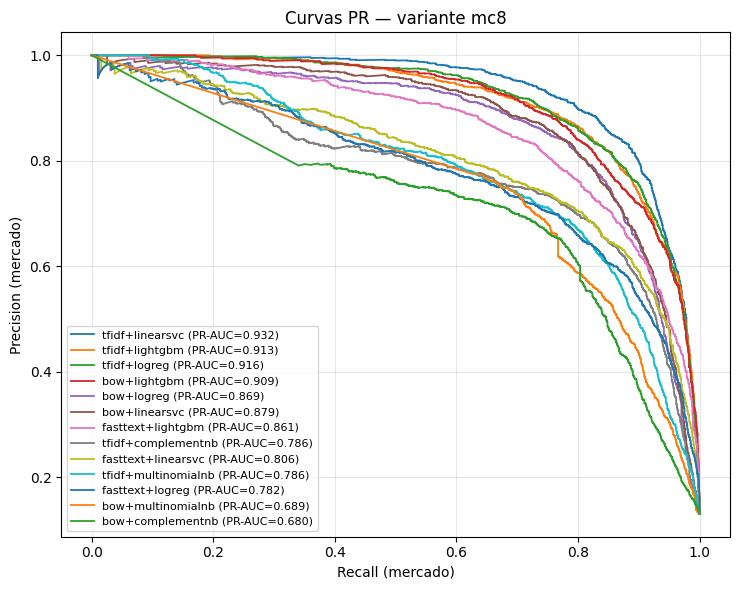

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for _, r in paired.sort_values('f1_minority_mc8', ascending=False).iterrows():
    pred = pd.read_csv(Path(r.run_dir_mc8) / 'predictions.csv')
    prec, rec, _ = precision_recall_curve(pred.y_true, pred.y_score)
    ax.plot(rec, prec,
            label=f'{r.representation}+{r.model} (PR-AUC={r.pr_auc_mc8:.3f})',
            lw=1.3)
ax.set_xlabel('Recall (mercado)')
ax.set_ylabel('Precision (mercado)')
ax.set_title('Curvas PR — variante mc8')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Latência vs F1-min (trade-off Green-AI)

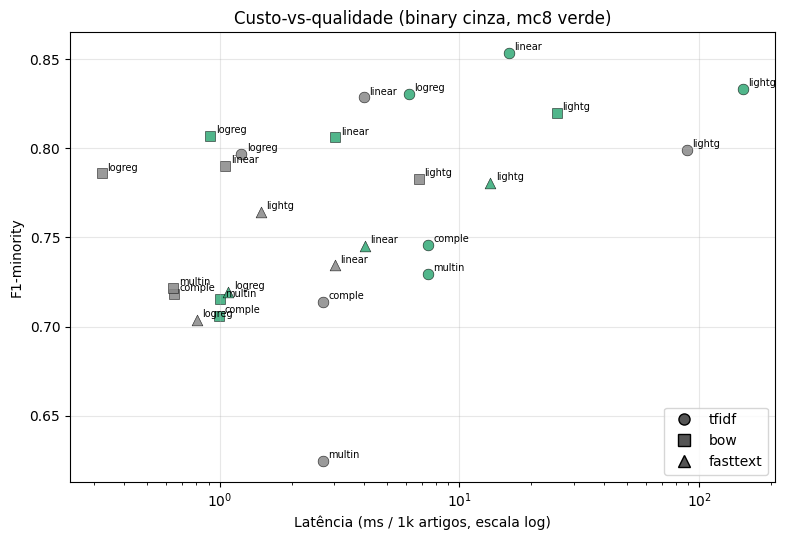

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {'bin': '#888', 'mc8': '#3a7'}
markers = {'tfidf': 'o', 'bow': 's', 'fasttext': '^'}
for _, r in summary.iterrows():
    ax.scatter(r.latency_ms_per_1k, r.f1_minority,
               color=colors[r.target_tag], marker=markers[r.representation],
               s=60, alpha=0.85, edgecolors='black', linewidths=0.4)
    ax.annotate(r.model[:6], (r.latency_ms_per_1k, r.f1_minority),
                xytext=(4, 2), textcoords='offset points', fontsize=7)
ax.set_xscale('log')
ax.set_xlabel('Latência (ms / 1k artigos, escala log)')
ax.set_ylabel('F1-minority')
ax.set_title('Custo-vs-qualidade (binary cinza, mc8 verde)')
handles = [plt.Line2D([0], [0], marker=m, color='w', markerfacecolor='#555',
                      markeredgecolor='k', markersize=8, label=name)
           for name, m in markers.items()]
ax.legend(handles=handles, loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 7. Campeão Gen 1


In [11]:
champ = summary.sort_values('f1_minority', ascending=False).iloc[0]
print(f'Campeão: {champ.representation}+{champ.model} ({champ.target_tag})')
print(f'  F1-min          : {champ.f1_minority:.4f}')
print(f'  PR-AUC          : {champ.pr_auc:.4f}')
print(f'  Precisão (min.) : {champ.precision_minority:.4f}')
print(f'  Recall (min.)   : {champ.recall_minority:.4f}')
print(f'  Threshold       : {champ.threshold:.2f}')
print(f'  Latência        : {champ.latency_ms_per_1k:.2f} ms / 1k')
print(f'  run_id          : {champ.run_id}')


Campeão: tfidf+linearsvc (mc8)
  F1-min          : 0.8536
  PR-AUC          : 0.9320
  Precisão (min.) : 0.8654
  Recall (min.)   : 0.8420
  Threshold       : 0.43
  Latência        : 16.09 ms / 1k
  run_id          : 20260421-220340__gen1__linearsvc__tfidf-aggr-mc8
